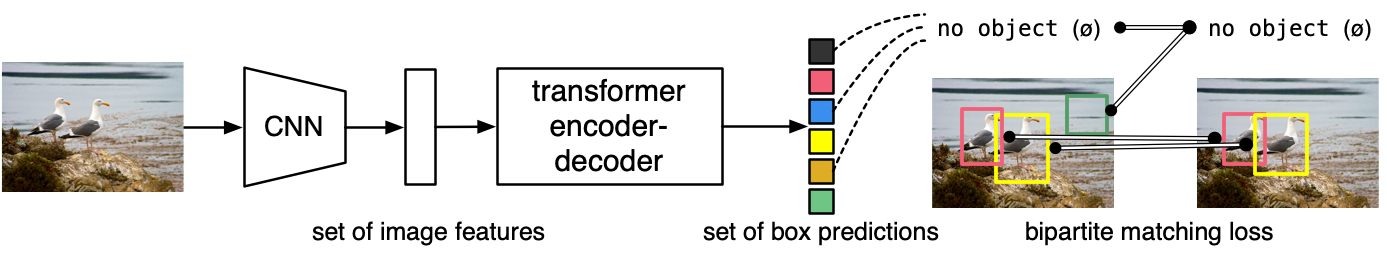

# Object Detection Using Transformers(LLM)

## Content
+ ### What is DETR?
+ ### Working
+ ### Object Detection using Pre-Trained Model
+ ### Custom data training
+ ### Inferencing

## DETR:
### DETR stands for Detection Transformer, a deep learning model that uses transformers to predict the bounding boxes and class labels of objects in an image. 
### With transformers, DETR can capture global context and relationships between objects in an image, leading to more accurate detections
### DETR makes object detection a direct set prediction problem. Its goal is to consider all the objects in the image as a set and predict their bounding boxes and classes in a single pass. This new approach improves the detection accuracy, especially when many objects are close to each other.

 # 


## Working

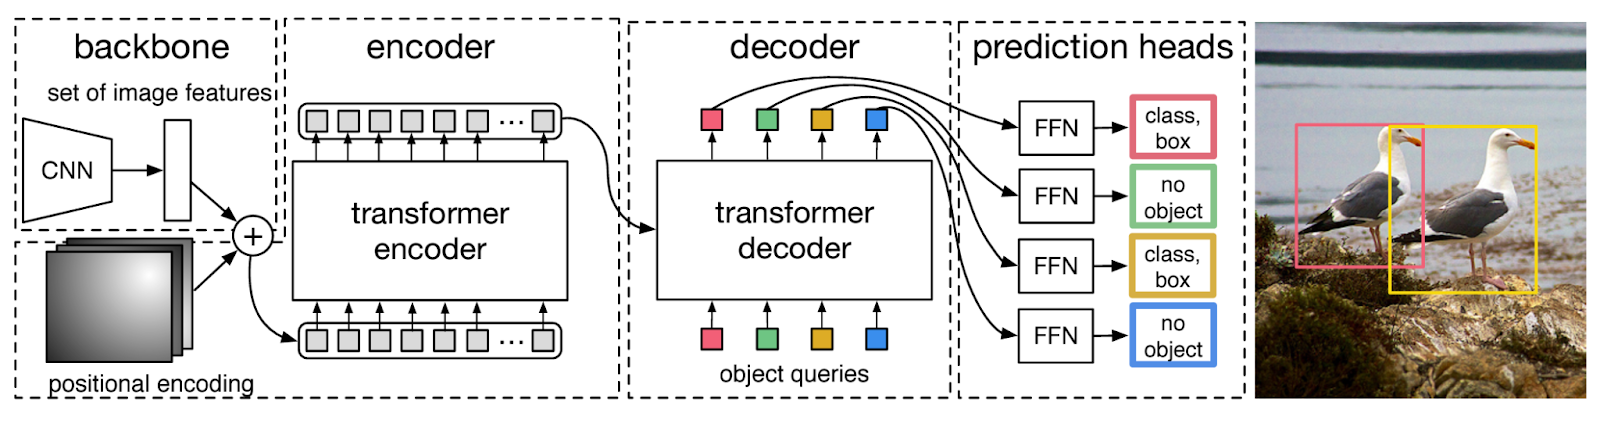

### The main components of DETR architecture are the Convolutional Neural Network (CNN) backbone, the transformer encoder and decoder, and the prediction heads.

1. ### CNN: This is the first component and backbone of DETR, where we first the image to CNN which takes the image as an input and yields the feature map for all the objects present in the image, which then pass to the transformer. Some of the famous CNN networks are ResNet and VGG.
2. ### Transformer:
   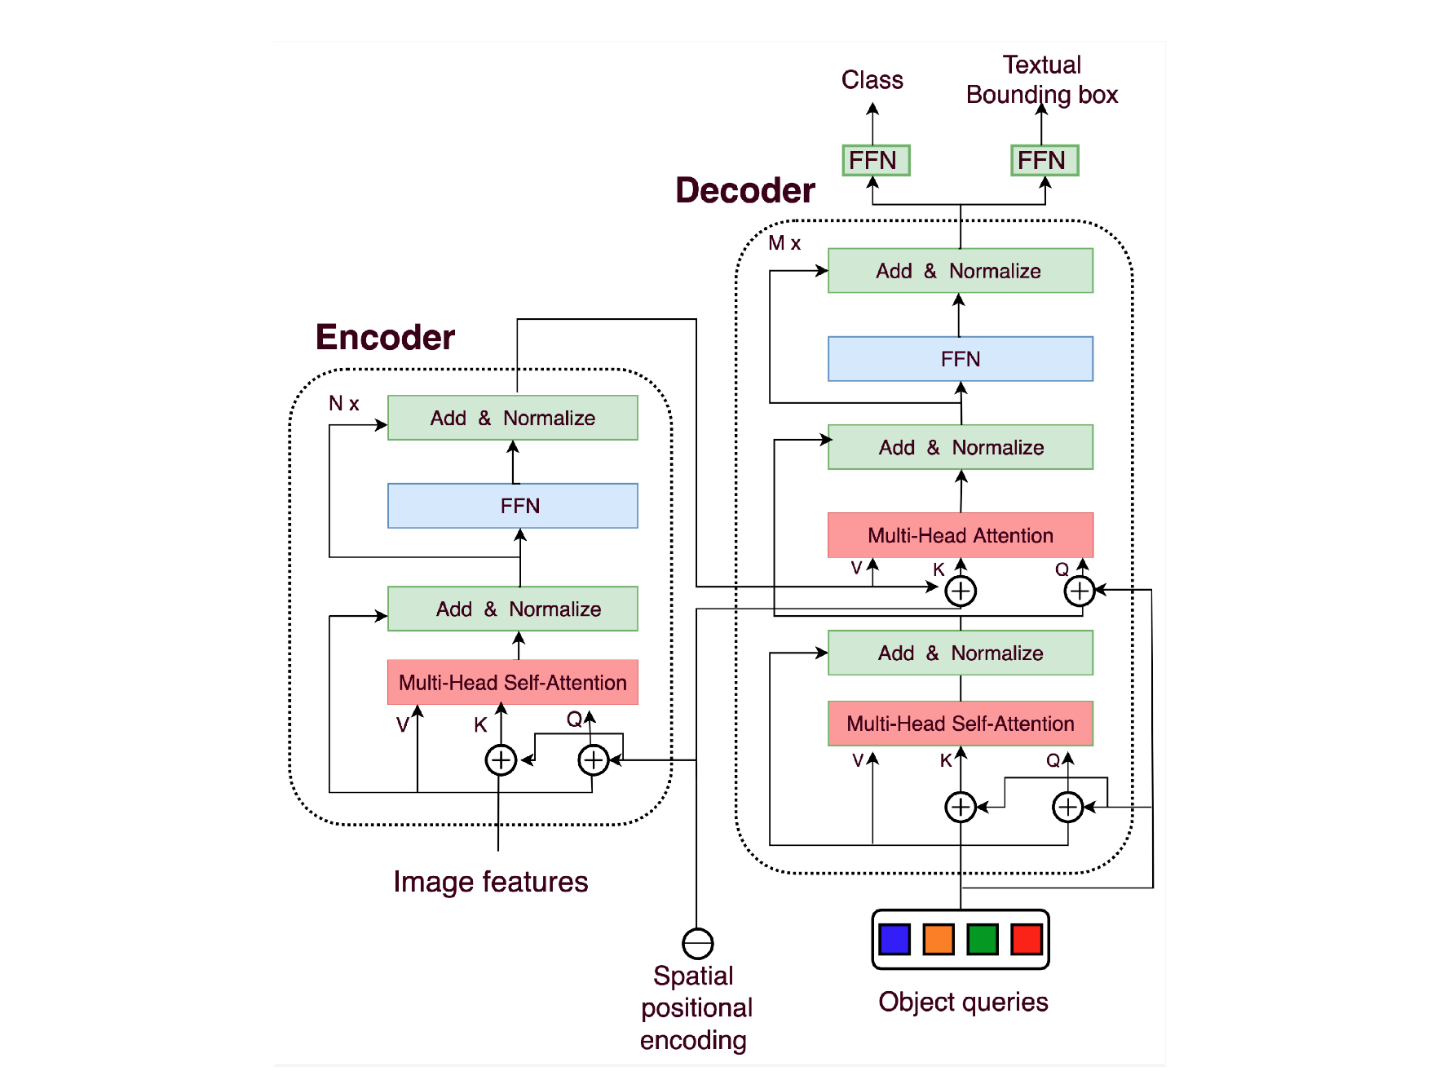
   ### The output of the CNN component is flatten features map. So Encoder takes that flatten feature map and encodes it. Before wee fee this input to transformer we add the positional encodings to the feature maps.
   ### As encoder contains multiheaded self attention blocks so it tries to capture contextual information between different parts of the image.
   ### Encoder gets to know about the relative position of objects through positional embeddings.
   ### The transformer decoder learns relationships between the CNN encoded features and the learnable object queries. Typically, we require queries, keys, and values to calculate self-attention in NLP. Therefore, in computer vision, DETR introduces the concept of object queries, which refer to the learnable representations of the objects the model needs to predict. The number of object queries is predetermined and remains fixed. The keys denote the spatial locations in the image, while the values contain information about the features.
   ####
3. ### Prediction Heads: The prediction heads output the bounding boxes and classes of the detected objects. They consist of feed-forward network heads that either predict the bounding box and class for the detected objects or a ‘no-object’ class for no detections. Furthermore, DETR employs the technique of bipartite matching to ensure that the predicted bounding boxes are associated with the ground truth objects. This method also helps refine the model training.
   

## Object detection using pretrained model

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" 

from transformers import DetrImageProcessor, DetrForObjectDetection
import torch
from PIL import Image
import requests

import cv2

import matplotlib.pyplot as plt
%matplotlib inline  
import supervision as sv

## reading image

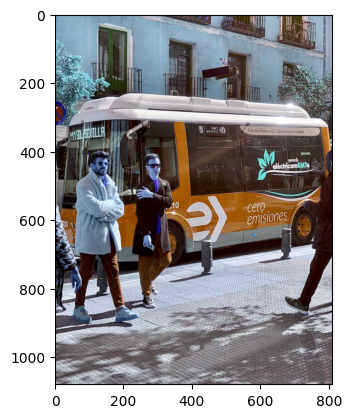

In [8]:
image = cv2.imread('bus.jpg')
plt.imshow(image)
plt.show()

## loading image preprocessor and model with same base model

In [3]:
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", revision="no_timm")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", revision="no_timm")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): ResNetBackbone(
          (embedder): ResNetEmbeddings(
            (embedder): ResNetConvLayer(
              (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
              (normalization): DetrFrozenBatchNorm2d()
              (activation): ReLU()
            )
            (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          )
          (encoder): ResNetEncoder(
            (stages): ModuleList(
              (0): ResNetStage(
                (layers): Sequential(
                  (0): ResNetBottleNeckLayer(
                    (shortcut): ResNetShortCut(
                      (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                      (normalization): DetrFrozenBatchNorm2d()
                    )
                    (layer): Seq

## preprocessing image and giving it to model

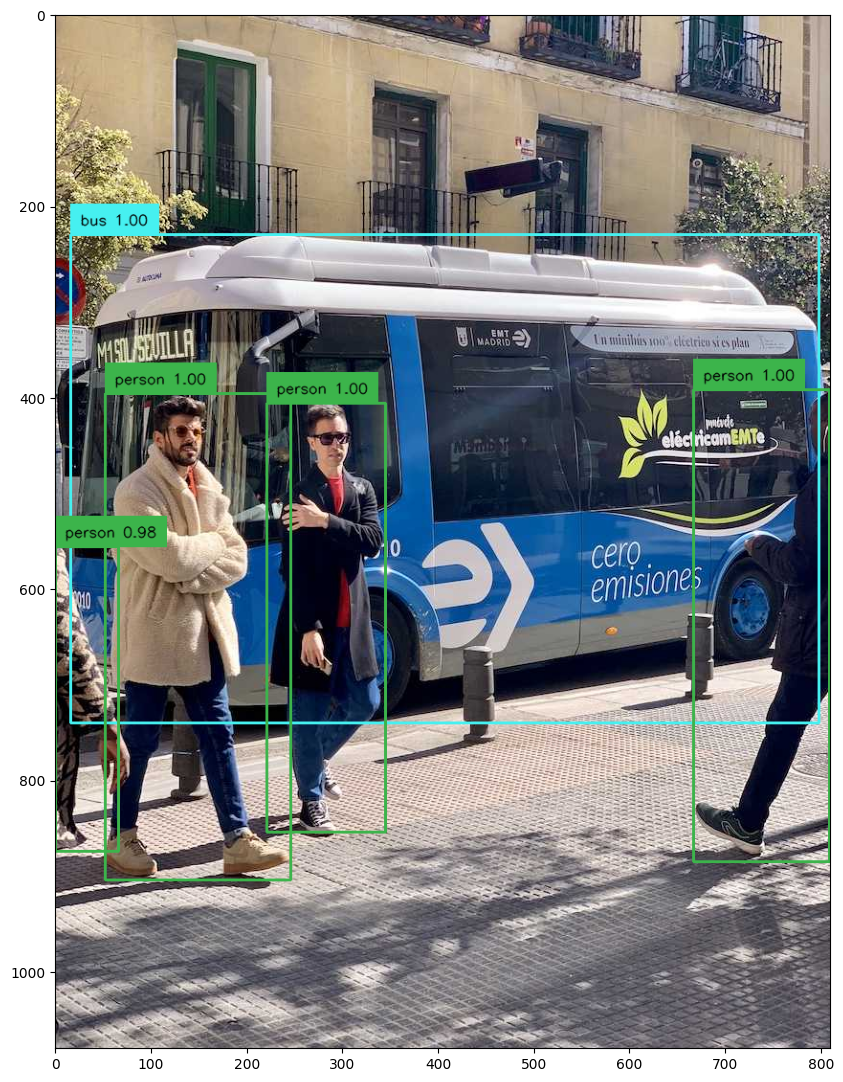

In [9]:
import torch
import supervision as sv

with torch.no_grad():

    inputs = processor(images=image, return_tensors='pt').to(device)
    outputs = model(**inputs)

    # post-process
    target_sizes = torch.tensor([image.shape[:2]]).to(device)
    results = processor.post_process_object_detection(
        outputs=outputs, 
        threshold=0.9, 
        target_sizes=target_sizes
    )[0]

# annotate
detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=0.9)

labels = [
    f"{model.config.id2label[class_id]} {confidence:0.2f}" 
    for _, confidence, class_id, _ 
    in detections
]

box_annotator = sv.BoxAnnotator()
frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)
sv.show_frame_in_notebook(frame, (10, 16))

## Visualizing results

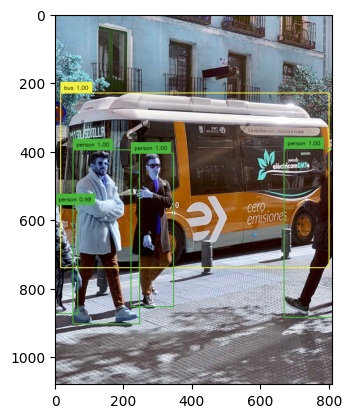

In [10]:
plt.imshow(frame)
plt.show()

## Live video inferencing

In [ ]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    image = frame.copy()

    with torch.no_grad():

        inputs = processor(images=image, return_tensors='pt').to(device)
        outputs = model(**inputs)
    
        # post-process
        target_sizes = torch.tensor([image.shape[:2]]).to(device)
        results = processor.post_process_object_detection(
            outputs=outputs, 
            threshold=0.9, 
            target_sizes=target_sizes
        )[0]

    # annotate
    detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=0.9)
    
    labels = [
        f"{model.config.id2label[class_id]} {confidence:0.2f}" 
        for _,_, confidence, class_id, _ 
        in detections
    ]
    
    box_annotator = sv.BoxAnnotator()
    frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)

    img = cv2.resize(frame, (1080, 720))
    
    cv2.imshow('YOLO', img)
        
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

## Model training on custom data

In [14]:
model = DetrForObjectDetection.from_pretrained('custom_model')
model.to(device)
categories = {0: {'id': 0, 'name': 'football-players-detection', 'supercategory': 'none'},
 1: {'id': 1, 'name': 'ball', 'supercategory': 'football-players-detection'},
 2: {'id': 2,
  'name': 'goalkeeper',
  'supercategory': 'football-players-detection'},
 3: {'id': 3, 'name': 'player', 'supercategory': 'football-players-detection'},
 4: {'id': 4,
  'name': 'referee',
  'supercategory': 'football-players-detection'}}

id2label = {k: v['name'] for k,v in categories.items()}

## inferencing using trained model

In [20]:
cap = cv2.VideoCapture('1094300071-preview.mp4')
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    image = frame.copy()

    with torch.no_grad():

        inputs = processor(images=image, return_tensors='pt').to(device)
        outputs = model(**inputs)
    
        # post-process
        target_sizes = torch.tensor([image.shape[:2]]).to(device)
        results = processor.post_process_object_detection(
            outputs=outputs, 
            threshold=0.7, 
            target_sizes=target_sizes
        )[0]

    # annotate
    detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=0.1)
    labels = [f"{id2label[class_id]} {confidence:0.2f}" 
        for _, confidence, class_id, _ 
        in detections]
    
    box_annotator = sv.BoxAnnotator()
    frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)

    img = cv2.resize(frame, (1080, 720))
    
    cv2.imshow('YOLO', img)
        
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()